In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [139]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [152]:
from google.colab import files
uploaded = files.upload()

Saving Clinical Text Data.csv to Clinical Text Data (2).csv


In [140]:
df = pd.read_csv("Clinical Text Data.csv", encoding='latin1')
df.head()

In [141]:
print(df.columns)
print(df.shape)
df['Label'].value_counts()

Index(['Id', 'Label', 'Text'], dtype='object')
(7501, 3)


,count
Label,
Thyroid Research,2810
Colorectal Studies,2511
Pulmonary Research,2180


In [142]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    return text

def clean_stopword(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

def tokenize(text):
    return word_tokenize(text)

In [143]:
df['final_text'] = df['Text'].apply(clean_text).apply(clean_stopword).apply(tokenize)
df.head()

,Id,Label,Text,final_text
0,0,Thyroid Research,Thyroid surgery in children in a single insti...,"[thyroid, surgery, children, single, instituti..."
1,1,Thyroid Research,""" The adopted strategy was the same as that us...","[adopted, strategy, used, prior, years, based,..."
2,2,Thyroid Research,coronary arterybypass grafting thrombosis ï¬b...,"[coronary, arterybypass, grafting, thrombosis,..."
3,3,Thyroid Research,Solitary plasmacytoma SP of the skull is an u...,"[solitary, plasmacytoma, sp, skull, uncommon, ..."
4,4,Thyroid Research,This study aimed to investigate serum matrix ...,"[study, aimed, investigate, serum, matrix, met..."


In [144]:
df['Label'] = df['Label'].astype('category').cat.codes

In [145]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'], df['Label'], test_size=0.3, random_state=42
)

In [146]:
vectorizer = TfidfVectorizer(max_features=300)

X_trn = vectorizer.fit_transform(X_train).toarray()
X_vld = vectorizer.transform(X_test).toarray()


**What this does**

1. **`sample_rows`** – You can add or remove row numbers here without changing the rest of the code.
2. The loop checks `if idx < len(df)` to ensure each index exists.
3. **`" ".join(...)`** turns the list of tokens in `final_text` back into a single string for easy reading.




In [147]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(300,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [148]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [149]:
epochs = 5

history = model.fit(
    X_trn, y_train,
    validation_data=(X_vld, y_test),
    epochs=epochs,
    batch_size=64
)

Epoch 1/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4746 - loss: 1.0095 - val_accuracy: 0.7157 - val_loss: 0.6058
Epoch 2/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7478 - loss: 0.5367 - val_accuracy: 0.7619 - val_loss: 0.4660
Epoch 3/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8125 - loss: 0.4142 - val_accuracy: 0.8276 - val_loss: 0.3878
Epoch 4/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8644 - loss: 0.3268 - val_accuracy: 0.8703 - val_loss: 0.3201
Epoch 5/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8944 - loss: 0.2659 - val_accuracy: 0.8778 - val_loss: 0.2855


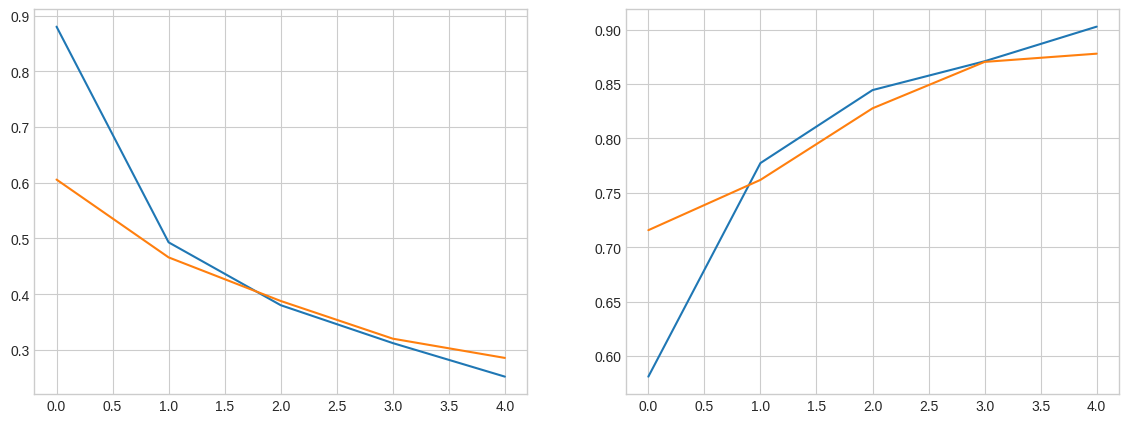

In [150]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


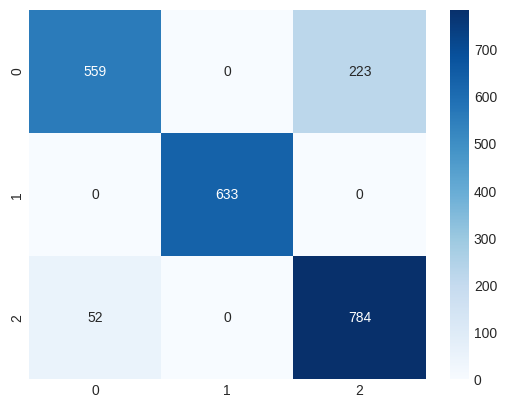

In [151]:
y_pred = model.predict(X_vld)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

### ✅ What is TF-IDF?

**TF-IDF** stands for **Term Frequency – Inverse Document Frequency**. It’s a popular technique in Natural Language Processing (NLP) used to convert raw text into **numerical features** that can be used in machine learning models for tasks like **text classification**, **clustering**, or **information retrieval**.

---

### 📌 TF-IDF = TF × IDF

#### 1. **TF (Term Frequency):**

It measures **how often a word appears in a document**.

$$
TF(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}
$$

The more a word appears in a document, the higher its TF.

#### 2. **IDF (Inverse Document Frequency):**

It measures **how unique or rare a word is across all documents**.

$$
IDF(t) = \log \left( \frac{\text{Total number of documents}}{\text{Number of documents containing the term } t} \right)
$$

* Common words like “the” or “and” have **low IDF** (appear in almost every document).
* Rare or domain-specific words have **high IDF**.

---

### 💡 Why use TF-IDF?

* Words that appear **frequently in one document**, but **rarely across the entire corpus**, are likely to be **important** for classification or search.
* It **downweights common words** and **upweights meaningful ones**.

---

### 🧠 Example:

Imagine two medical documents:

* Doc 1: “**thyroid** cancer treatment”
* Doc 2: “**lung** cancer treatment”

The word **“cancer”** appears in both – it’s common → low IDF
But **“thyroid”** and **“lung”** appear in only one → high IDF → they become more important for distinguishing topics.




## LSTM

### 🧠 What is LSTM?

**LSTM** stands for **Long Short-Term Memory**. It is a type of **Recurrent Neural Network (RNN)** that is especially good at learning from **sequences of data**, like sentences, time series, or audio signals.

---

### ✅ Why was LSTM created?

Standard RNNs have a problem:
They **forget long-term dependencies** due to something called the **vanishing gradient problem**.

LSTM fixes this by adding a **memory cell** and a set of **gates** that control what to remember and what to forget.

---

### 🔍 LSTM Architecture:

Each LSTM unit has:

#### 1. **Cell State (`Ct`)**

The memory of the network – carries information across the entire sequence.

#### 2. **Forget Gate (`ft`)**

Decides **what to remove** from the memory.
Uses a sigmoid activation:

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

#### 3. **Input Gate (`it`)**

Decides **what new information to store**.

$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

#### 4. **Candidate Memory (`Ĉt`)**

New potential content to add:

$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

#### 5. **Update Cell State:**

$$
C_t = f_t * C_{t-1} + i_t * \tilde{C}_t
$$

#### 6. **Output Gate (`ot`)**

Controls what part of memory becomes output:

$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t * \tanh(C_t)
$$

---

### 📊 Summary:

| Component   | Function                |
| ----------- | ----------------------- |
| Forget Gate | Discards unneeded info  |
| Input Gate  | Adds new useful info    |
| Cell State  | Stores long-term memory |
| Output Gate | Sends useful output     |

---

### 🧠 What is LSTM good for?

* Sentiment analysis
* Machine translation
* Speech recognition
* Stock prediction
* Medical text classification (like your dataset)





### 📌 Explanation:

* **`loss='categorical_crossentropy'`**

  * This is the loss function used when your target variable (`y`) is one-hot encoded (e.g., `[1, 0, 0]`, `[0, 1, 0]`, `[0, 0, 1]`).
  * It's a standard choice for multi-class classification problems.
  * If your labels are just integers like `0`, `1`, `2` (not one-hot encoded), you should use `'sparse_categorical_crossentropy'` instead.

* **`optimizer='adam'`**

  * Adam is an adaptive optimizer that combines momentum and learning rate scheduling.
  * It's efficient and generally a good default choice for deep learning tasks.

* **`metrics=['accuracy']`**

  * This tells the model to track accuracy during training and evaluation.

